# Gene Window Chromatin Analysis
March 5, 2024

Examine the chromatin data around gene +1s to identify potential technical or biological reasons for enrichment at timepoints 60-70 and 130-140 minutes.

1. Collect MNase-seq data around gene +1s (computed separately)
    - Window of 3 kb
    - Flip if gene is a crick gene
2. Normalize the data based on length distribution.
    - "fix" csv file, removes the chromosome 12 ribosomal DNA reads.
3. Plot as a heatmap of all genes.
    - How do we plot these for all genes for all timepoints?


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


Retrieving file: output/mnase/yl_rep1_mnase_reads/yl_rep1_mnase_reads_chr10.h5 from disk.
0/340 - 00:00:05.47
100/340 - 00:01:12.14
200/340 - 00:02:19.32
300/340 - 00:03:26.26
339/340 - 00:03:51.60
Retrieving file: output/mnase/yl_rep1_mnase_reads/yl_rep1_mnase_reads_chr3.h5 from disk.
0/147 - 00:03:54.20
100/147 - 00:04:39.62
146/147 - 00:05:00.22
Retrieving file: output/mnase/yl_rep1_mnase_reads/yl_rep1_mnase_reads_chr6.h5 from disk.
0/115 - 00:05:02.38
100/115 - 00:05:43.11
114/115 - 00:05:48.72
Retrieving file: output/mnase/yl_rep1_mnase_reads/yl_rep1_mnase_reads_chr5.h5 from disk.
0/264 - 00:05:53.19
100/264 - 00:06:52.54
200/264 - 00:07:51.84
263/264 - 00:08:28.17
Retrieving file: output/mnase/yl_rep2_mnase_reads/yl_rep2_mnase_reads_chr10.h5 from disk.
0/340 - 00:08:33.78
100/340 - 00:09:39.23
200/340 - 00:10:45.79
300/340 - 00:11:52.40
339/340 - 00:12:18.00
Retrieving file: output/mnase/yl_rep2_mnase_reads/yl_rep2_mnase_reads_chr3.h5 from disk.
0/147 - 00:12:20.71
100/147 - 00:1

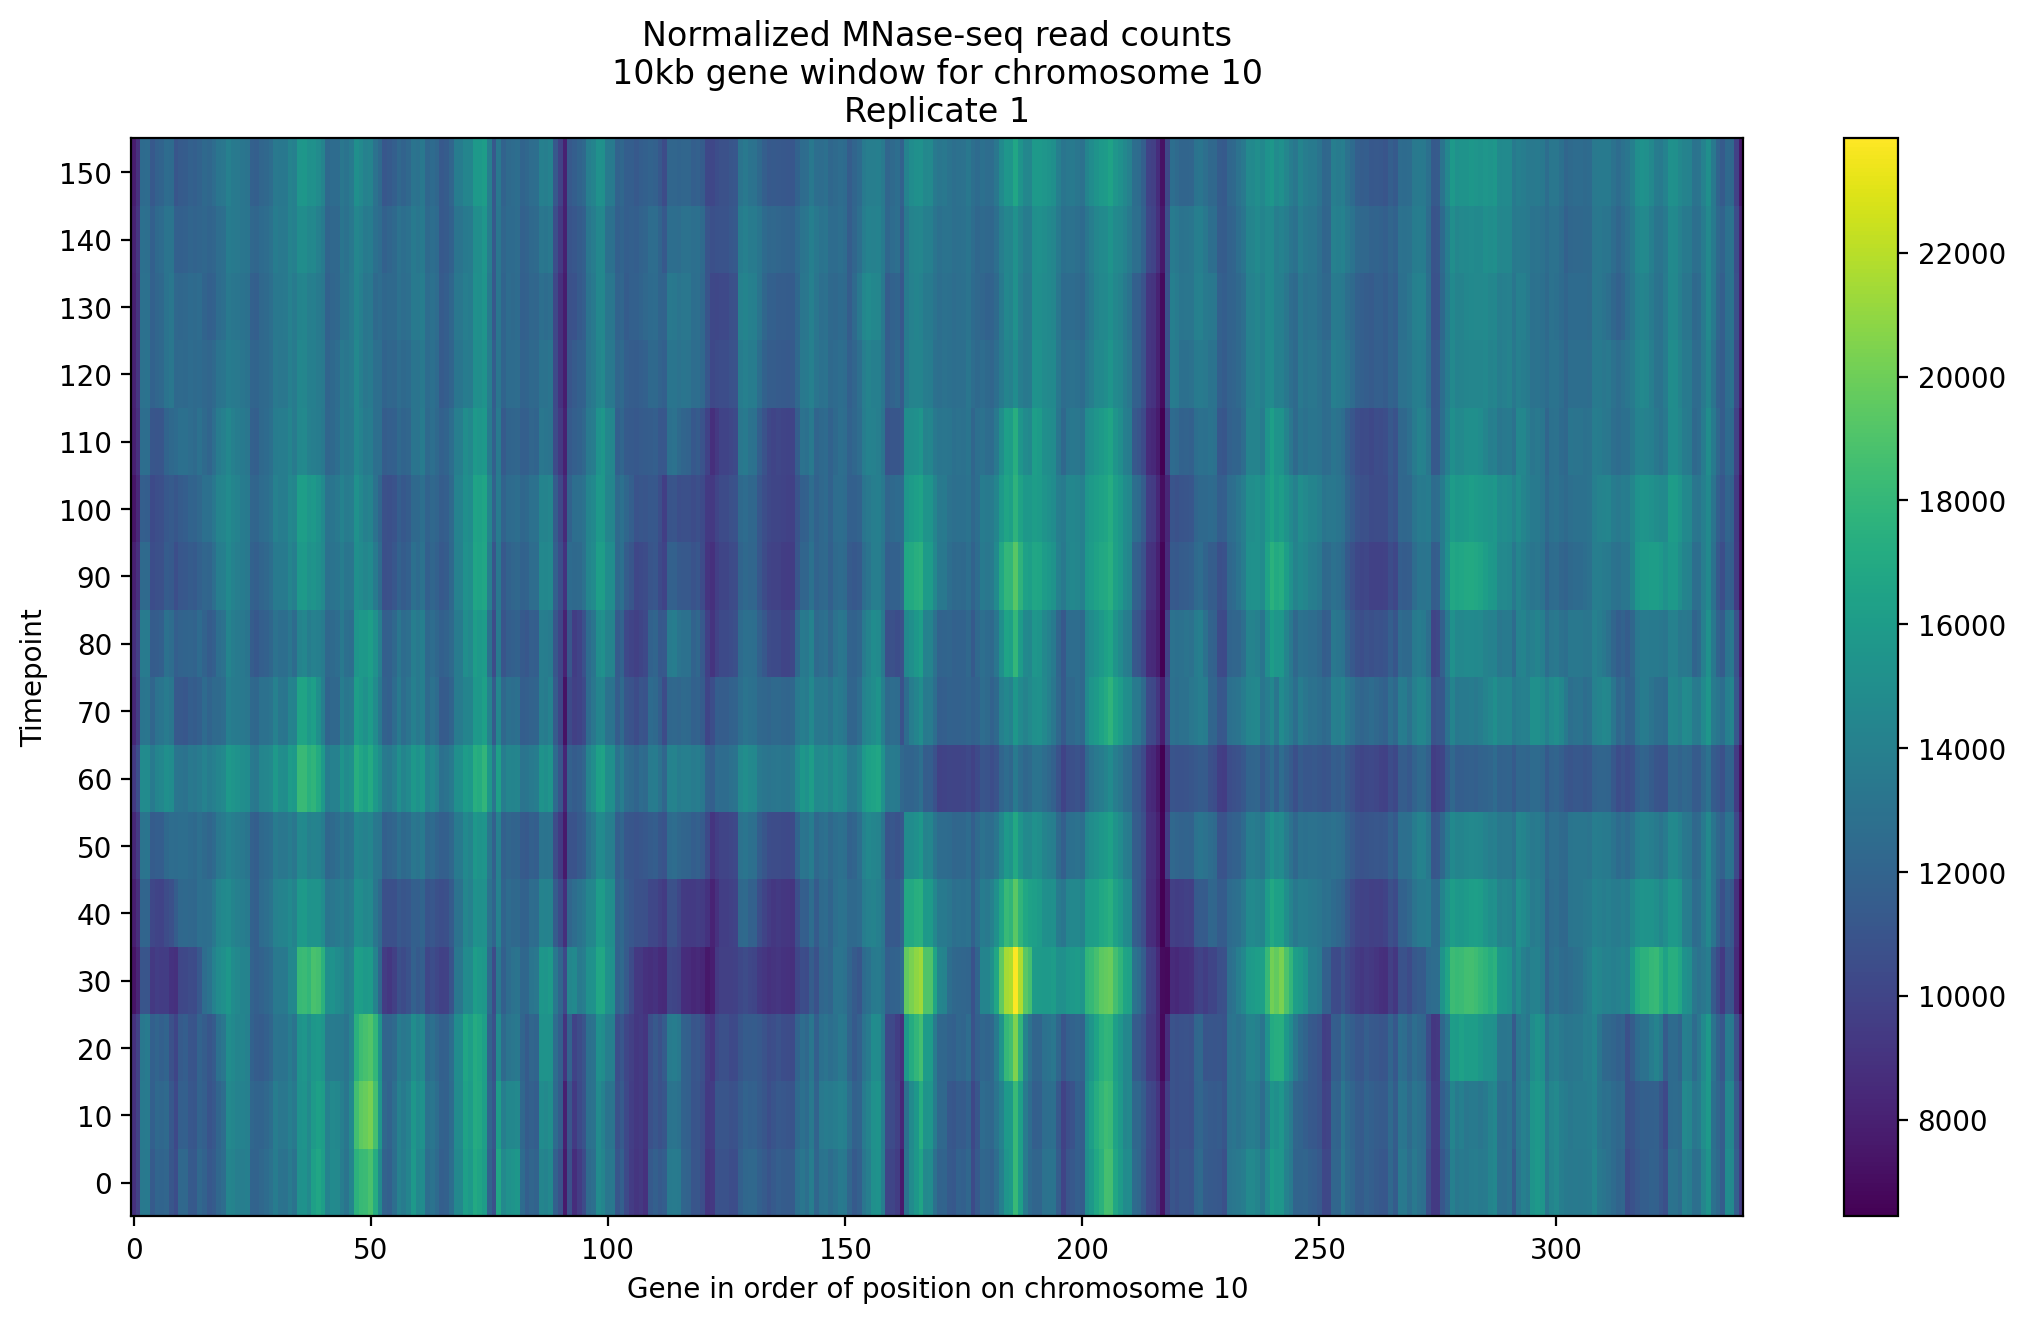

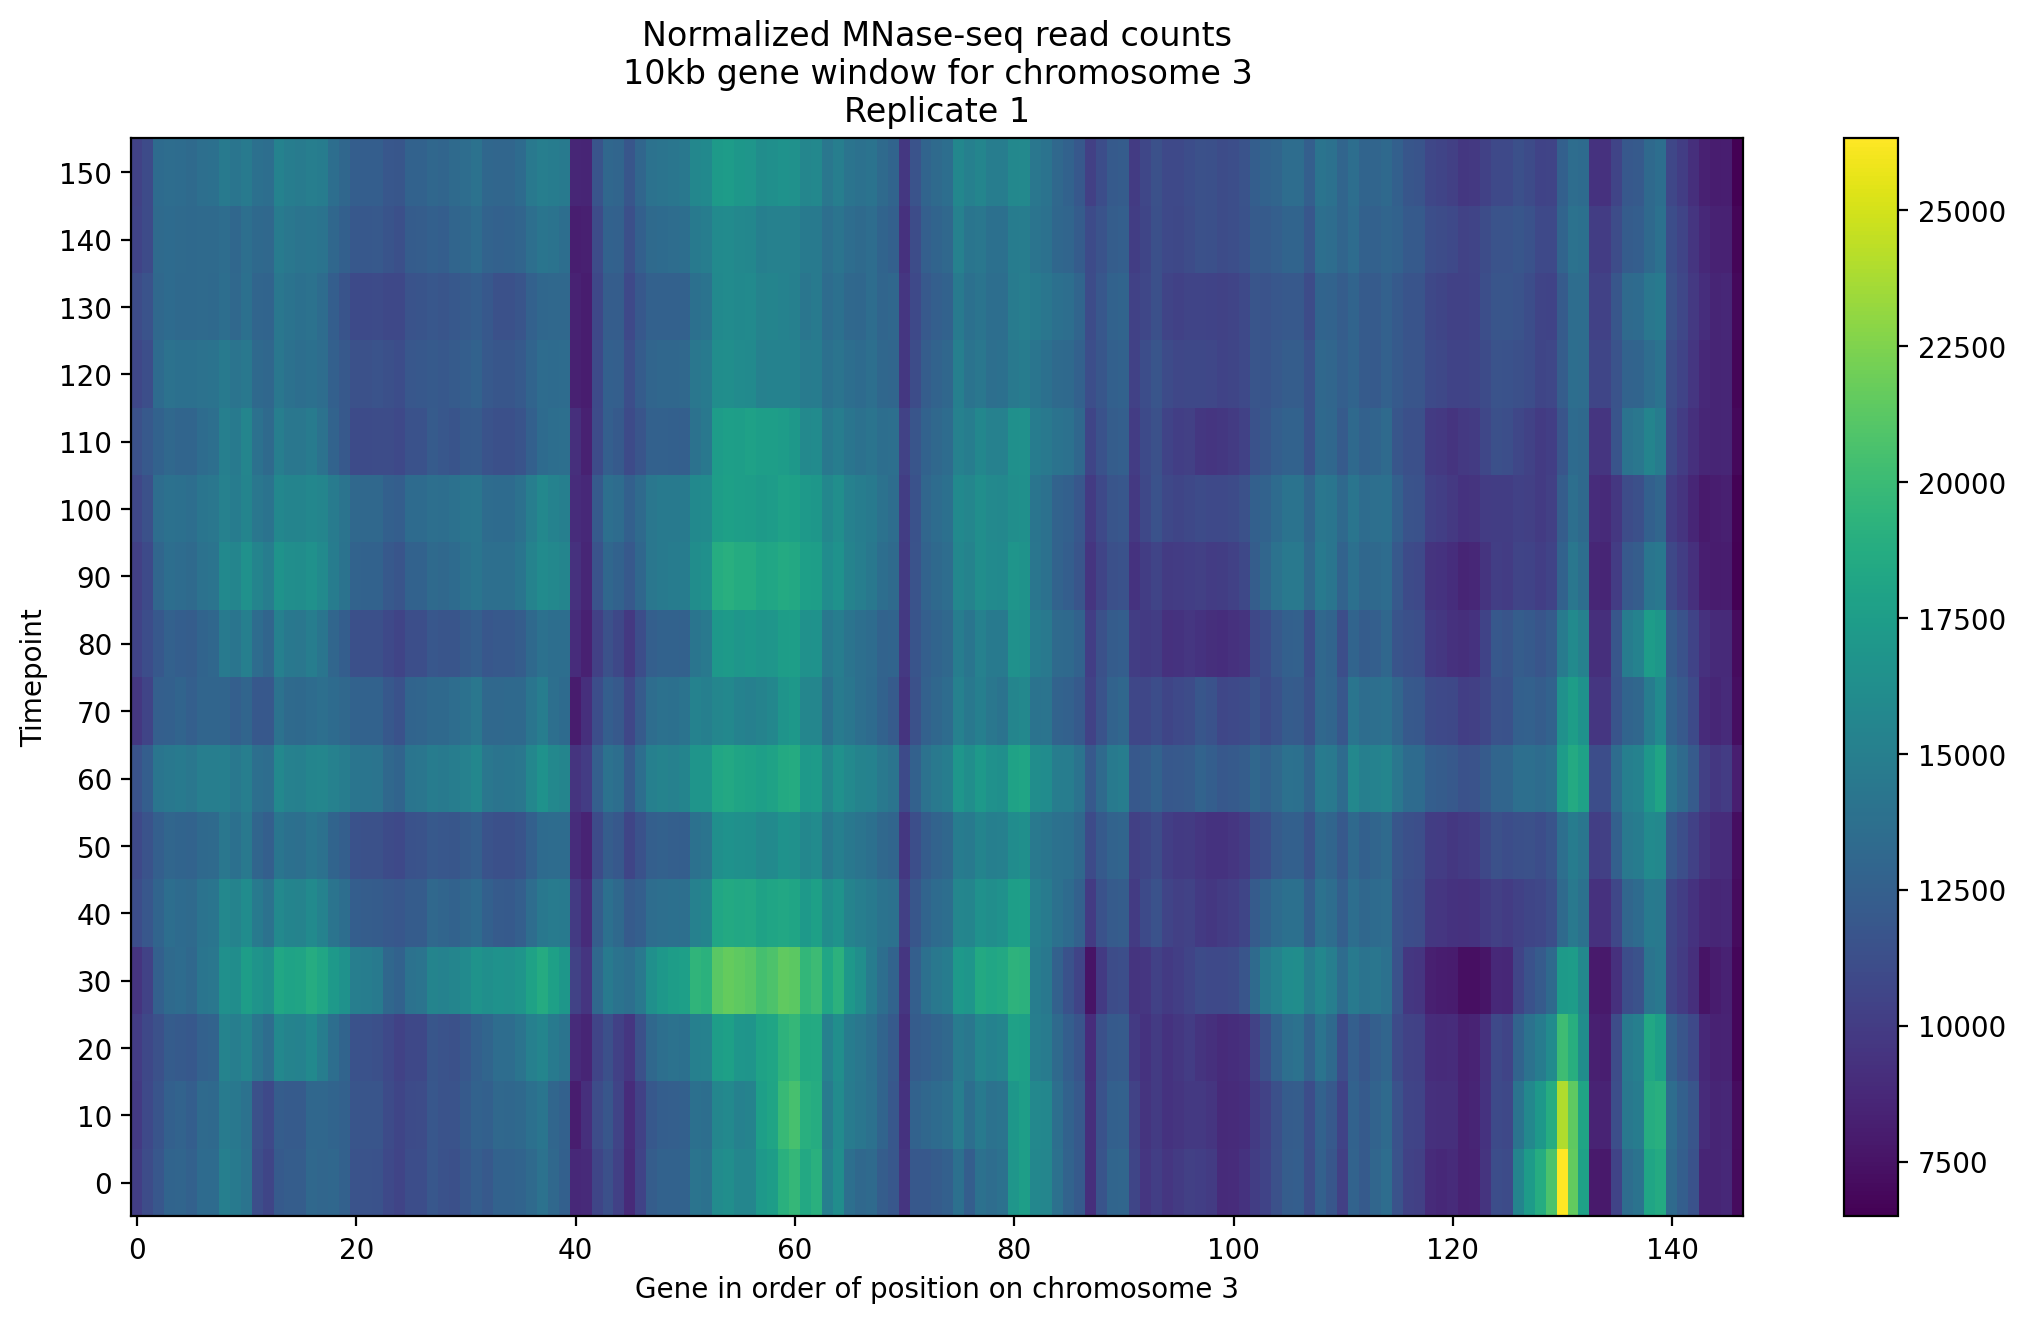

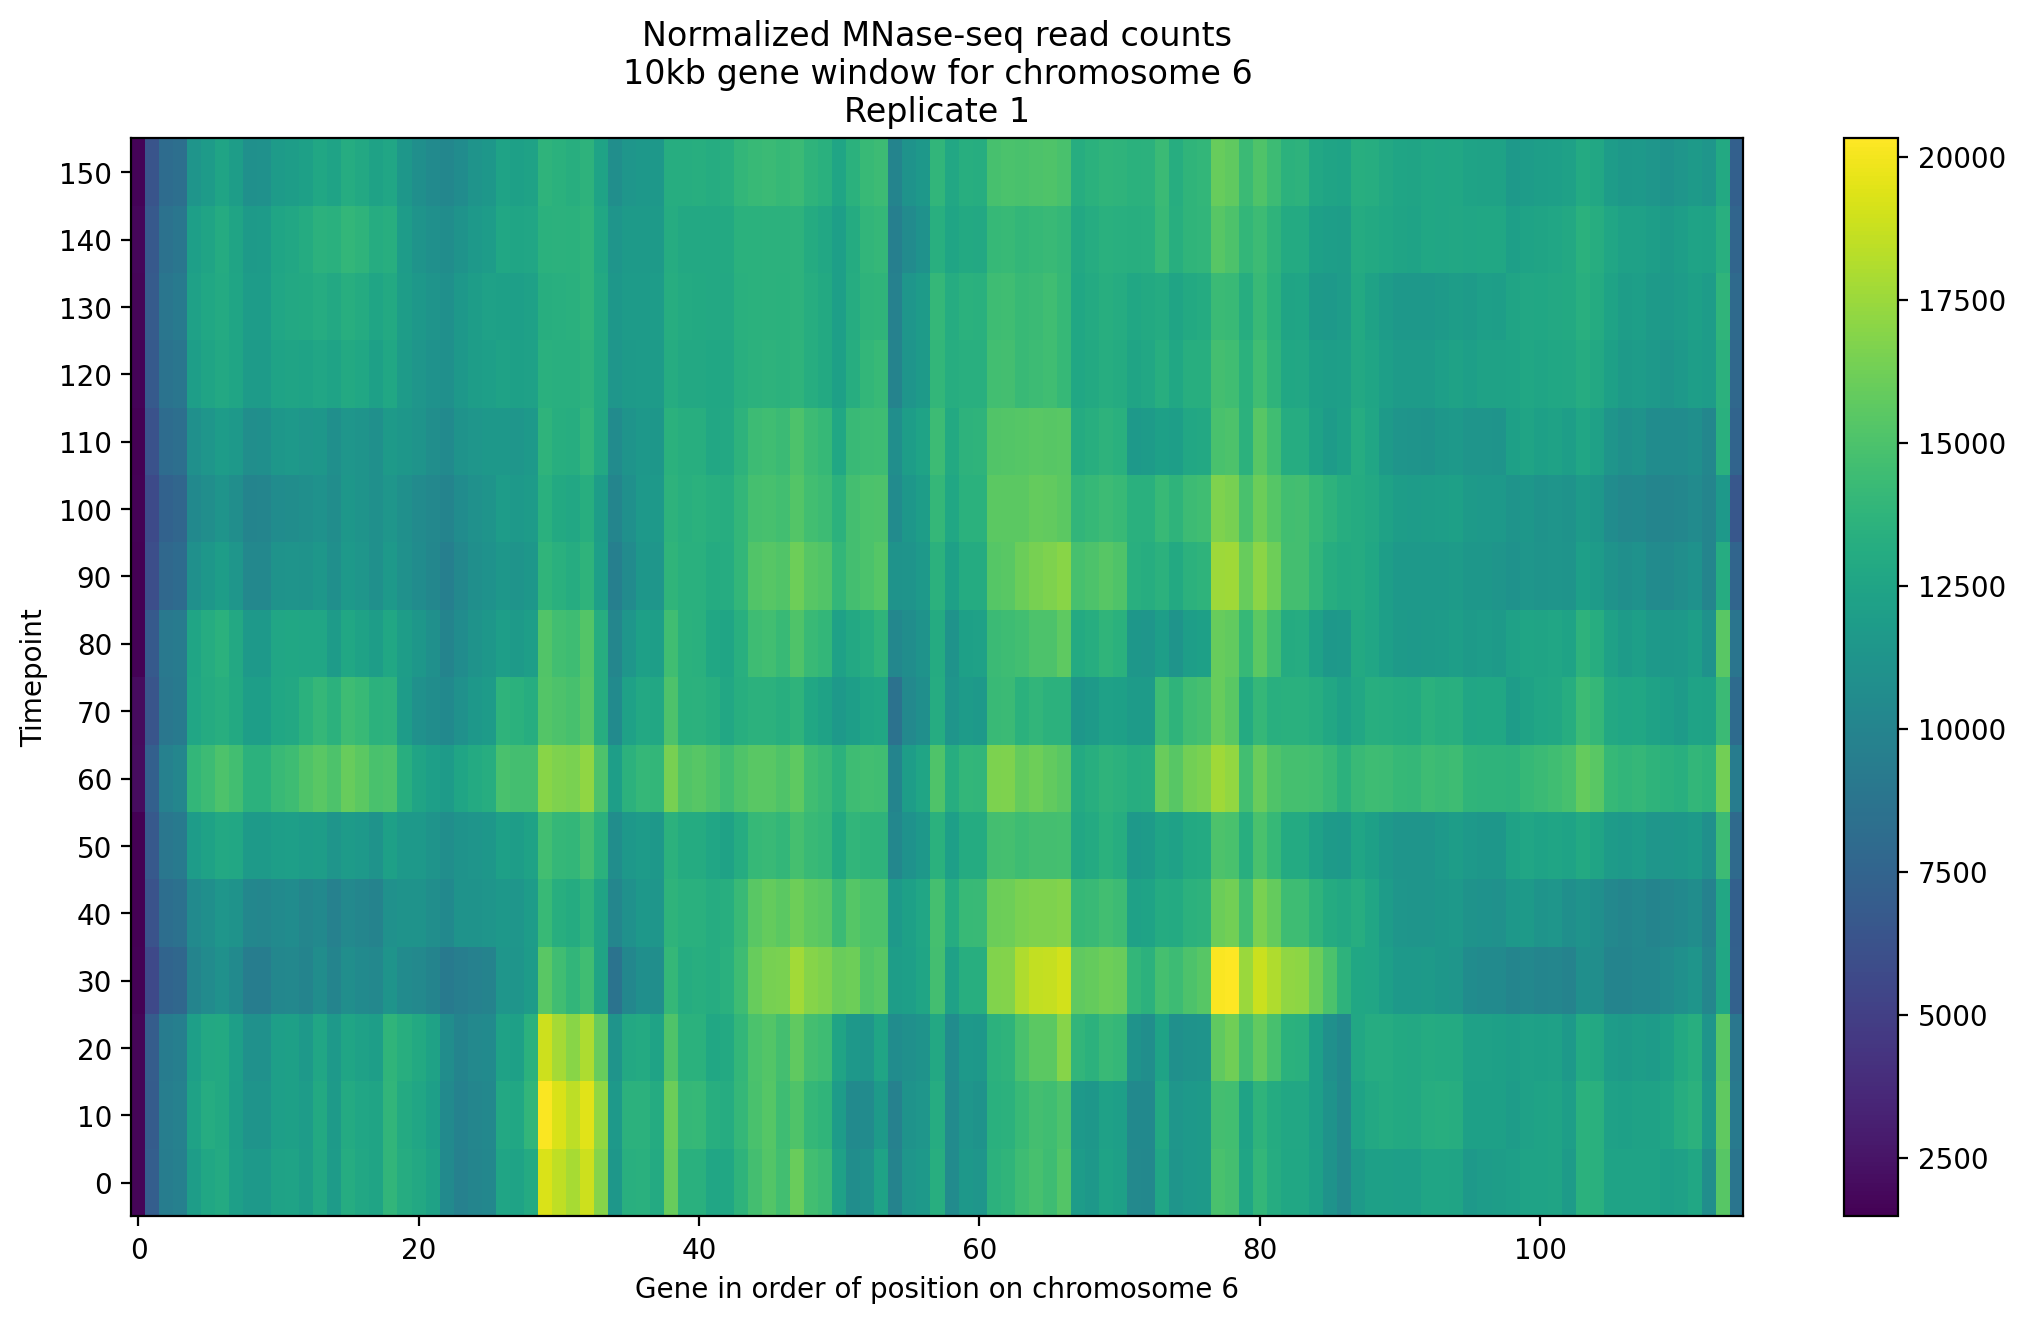

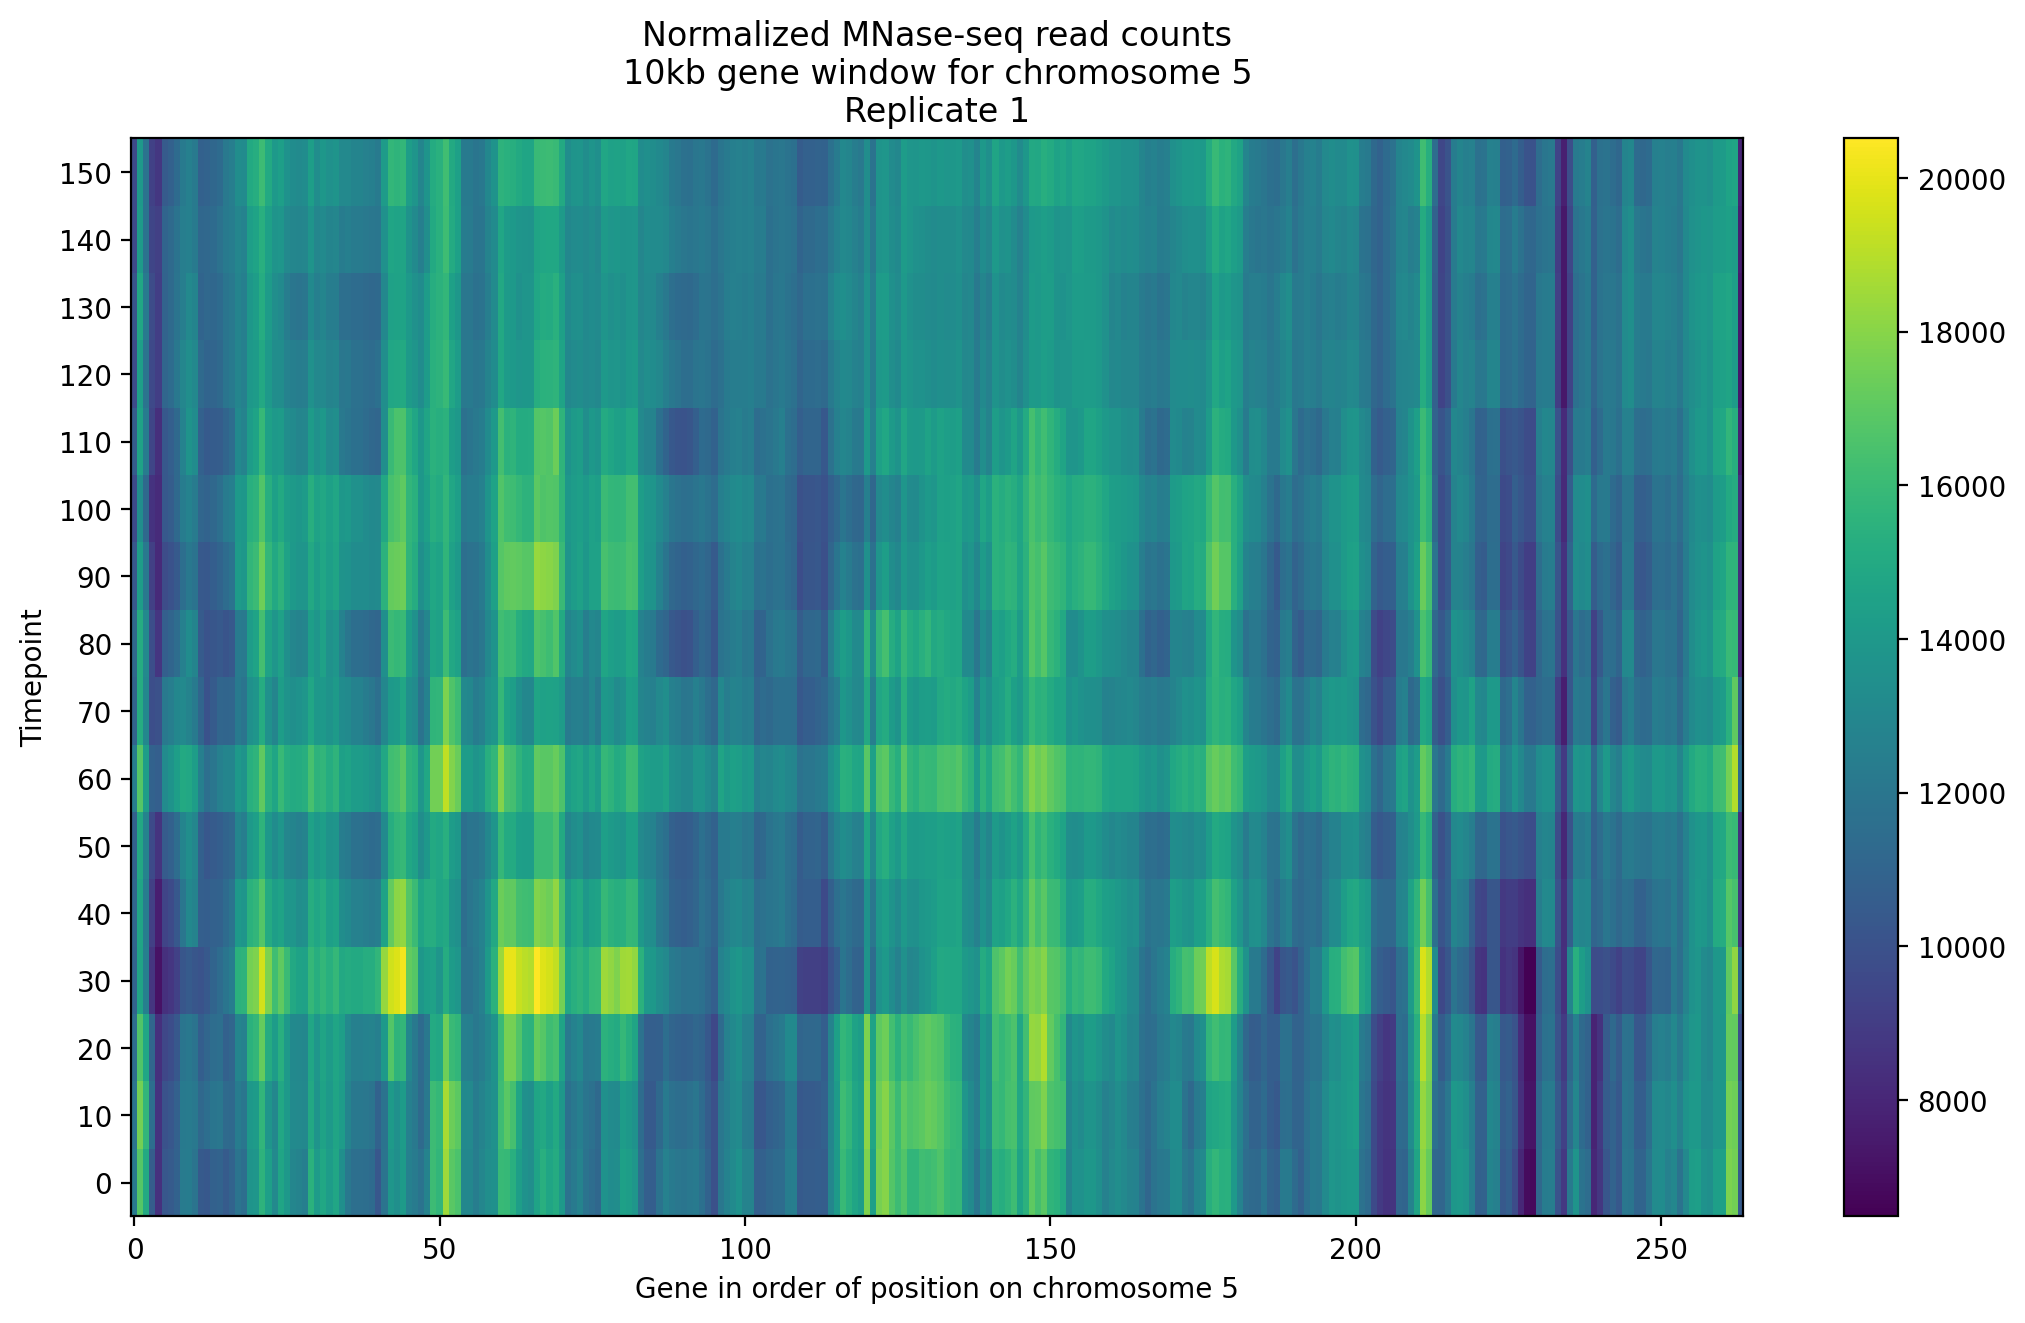

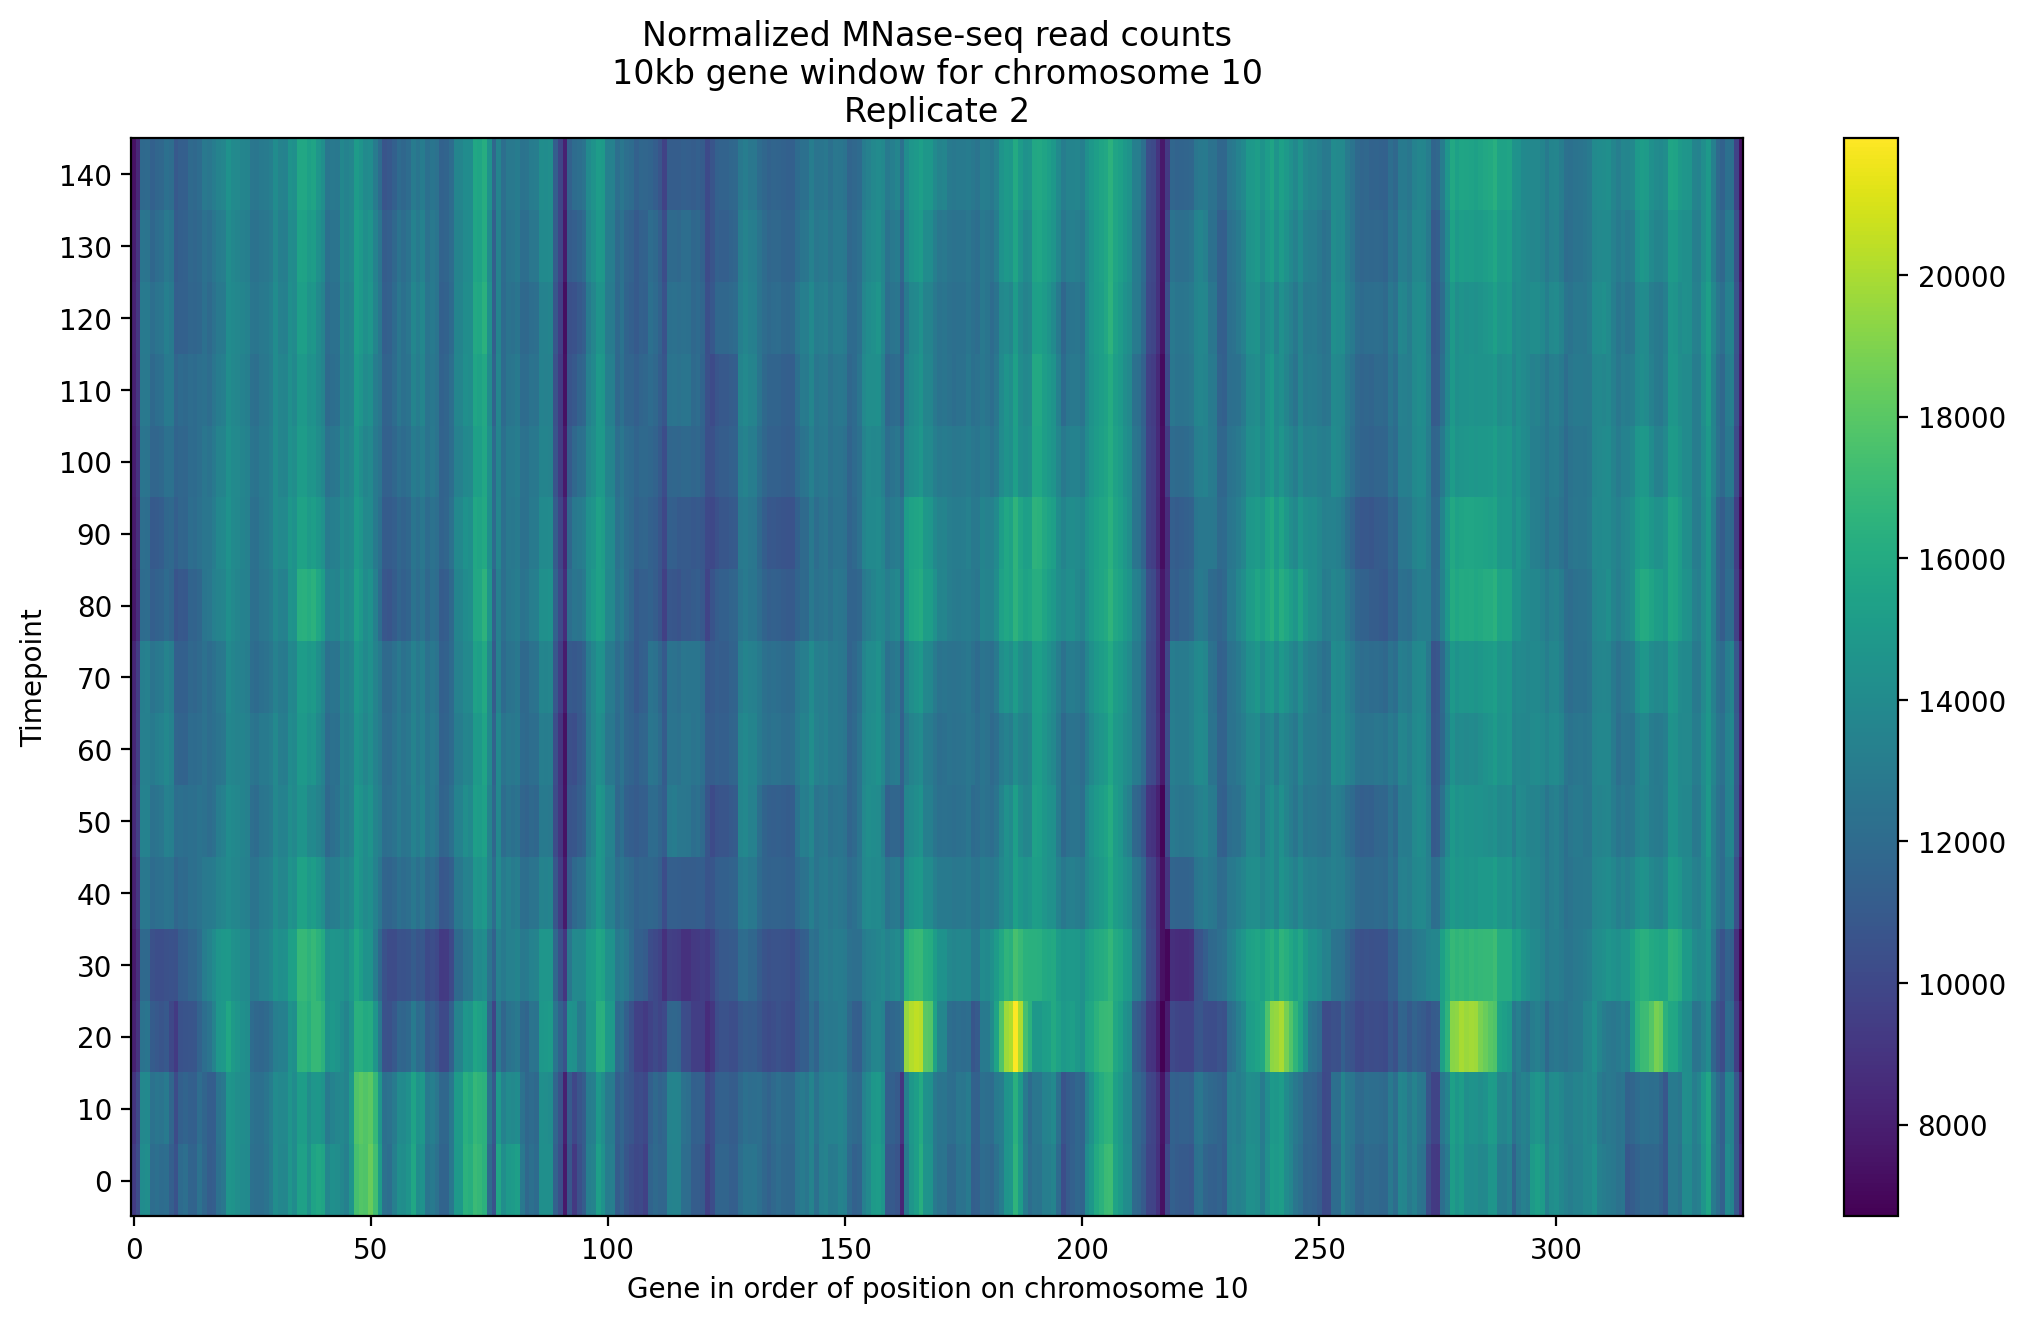

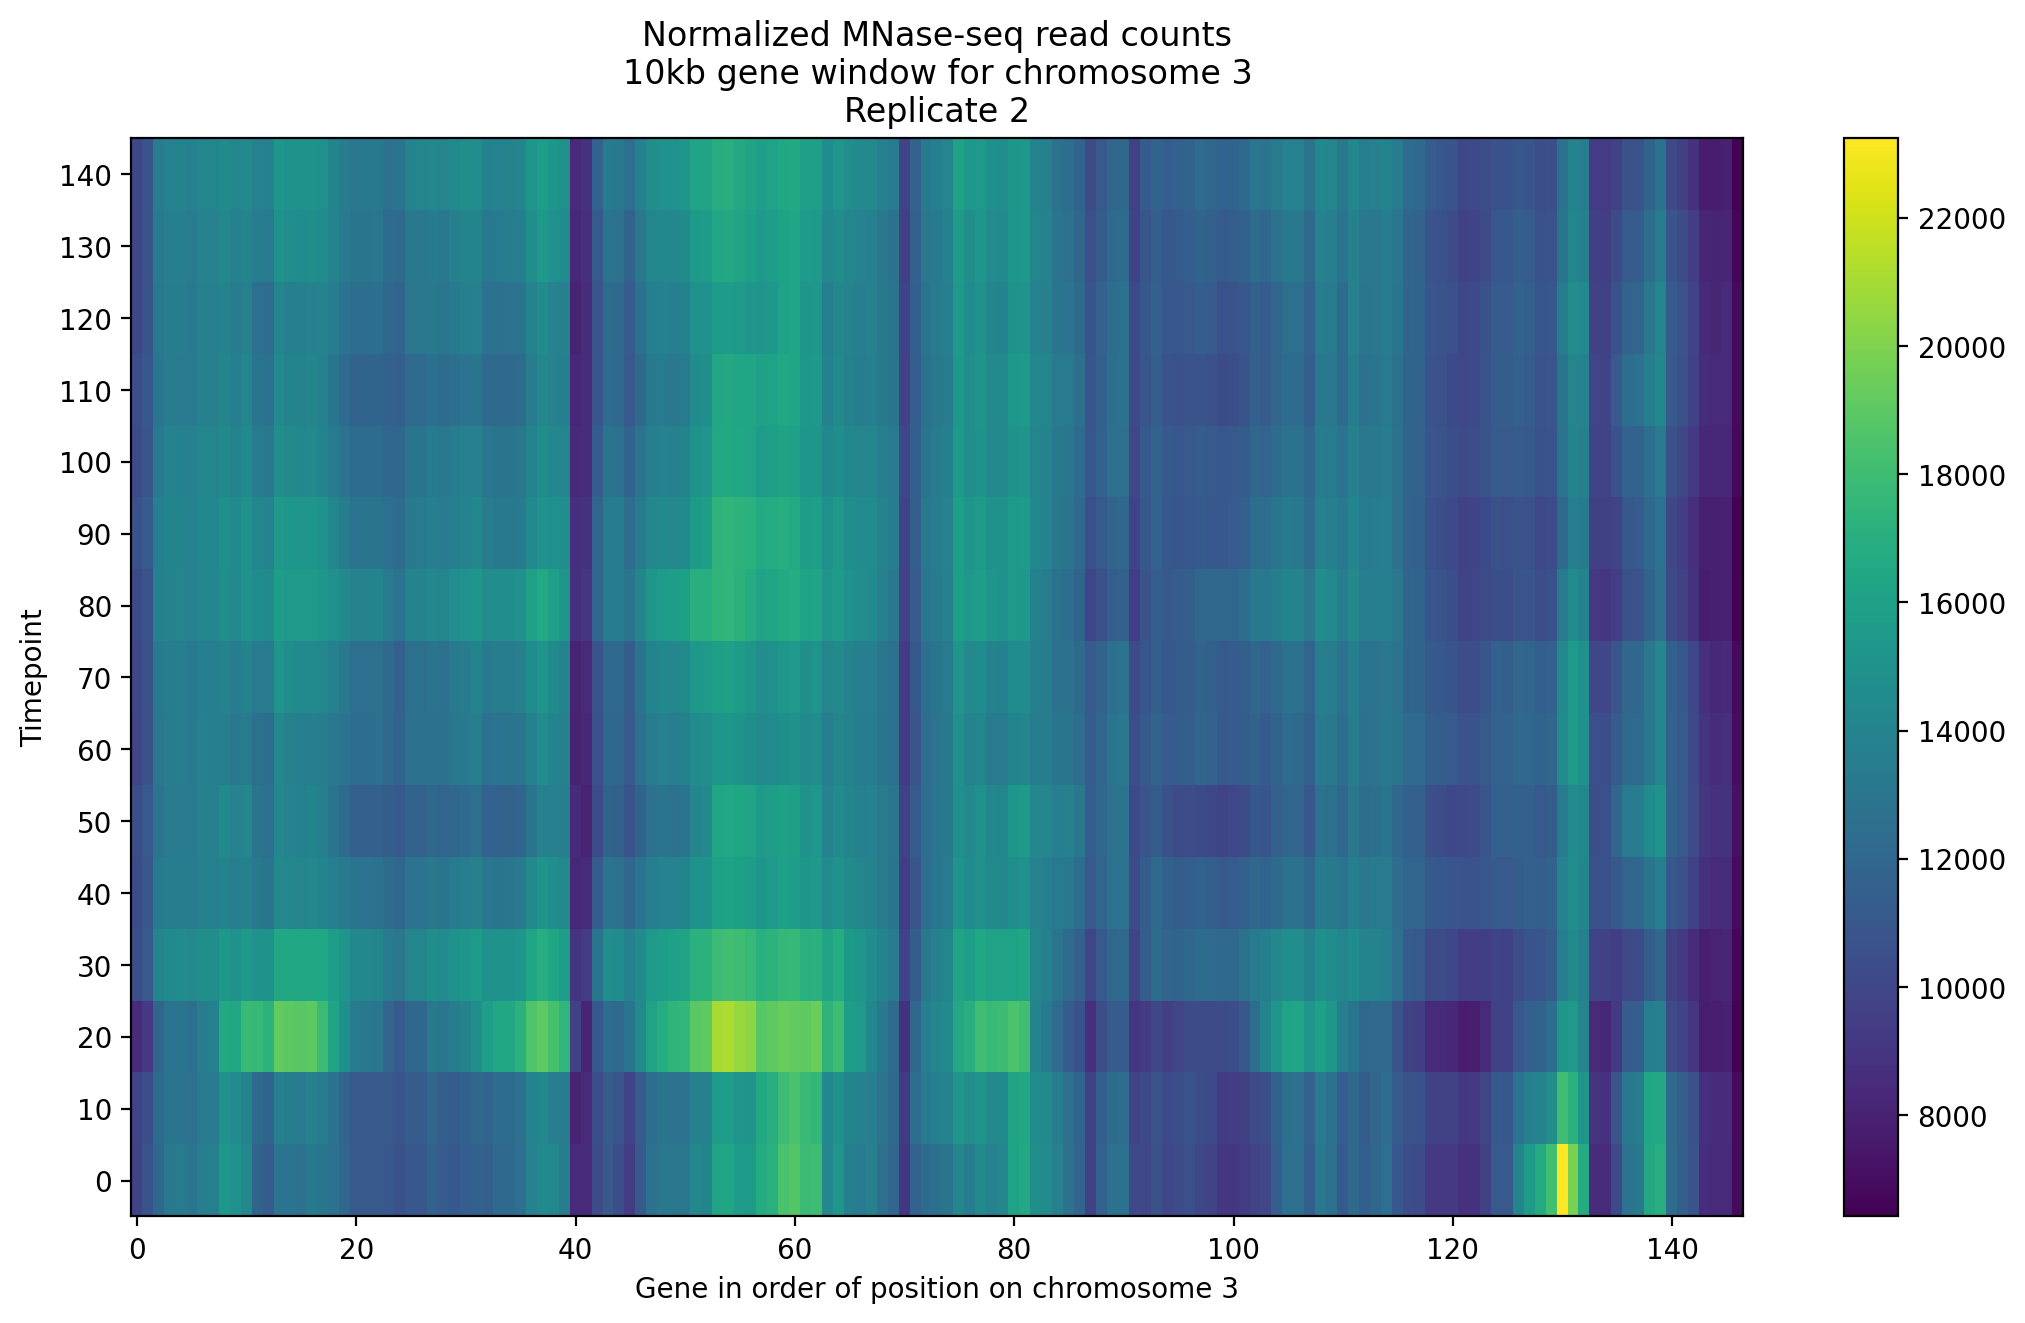

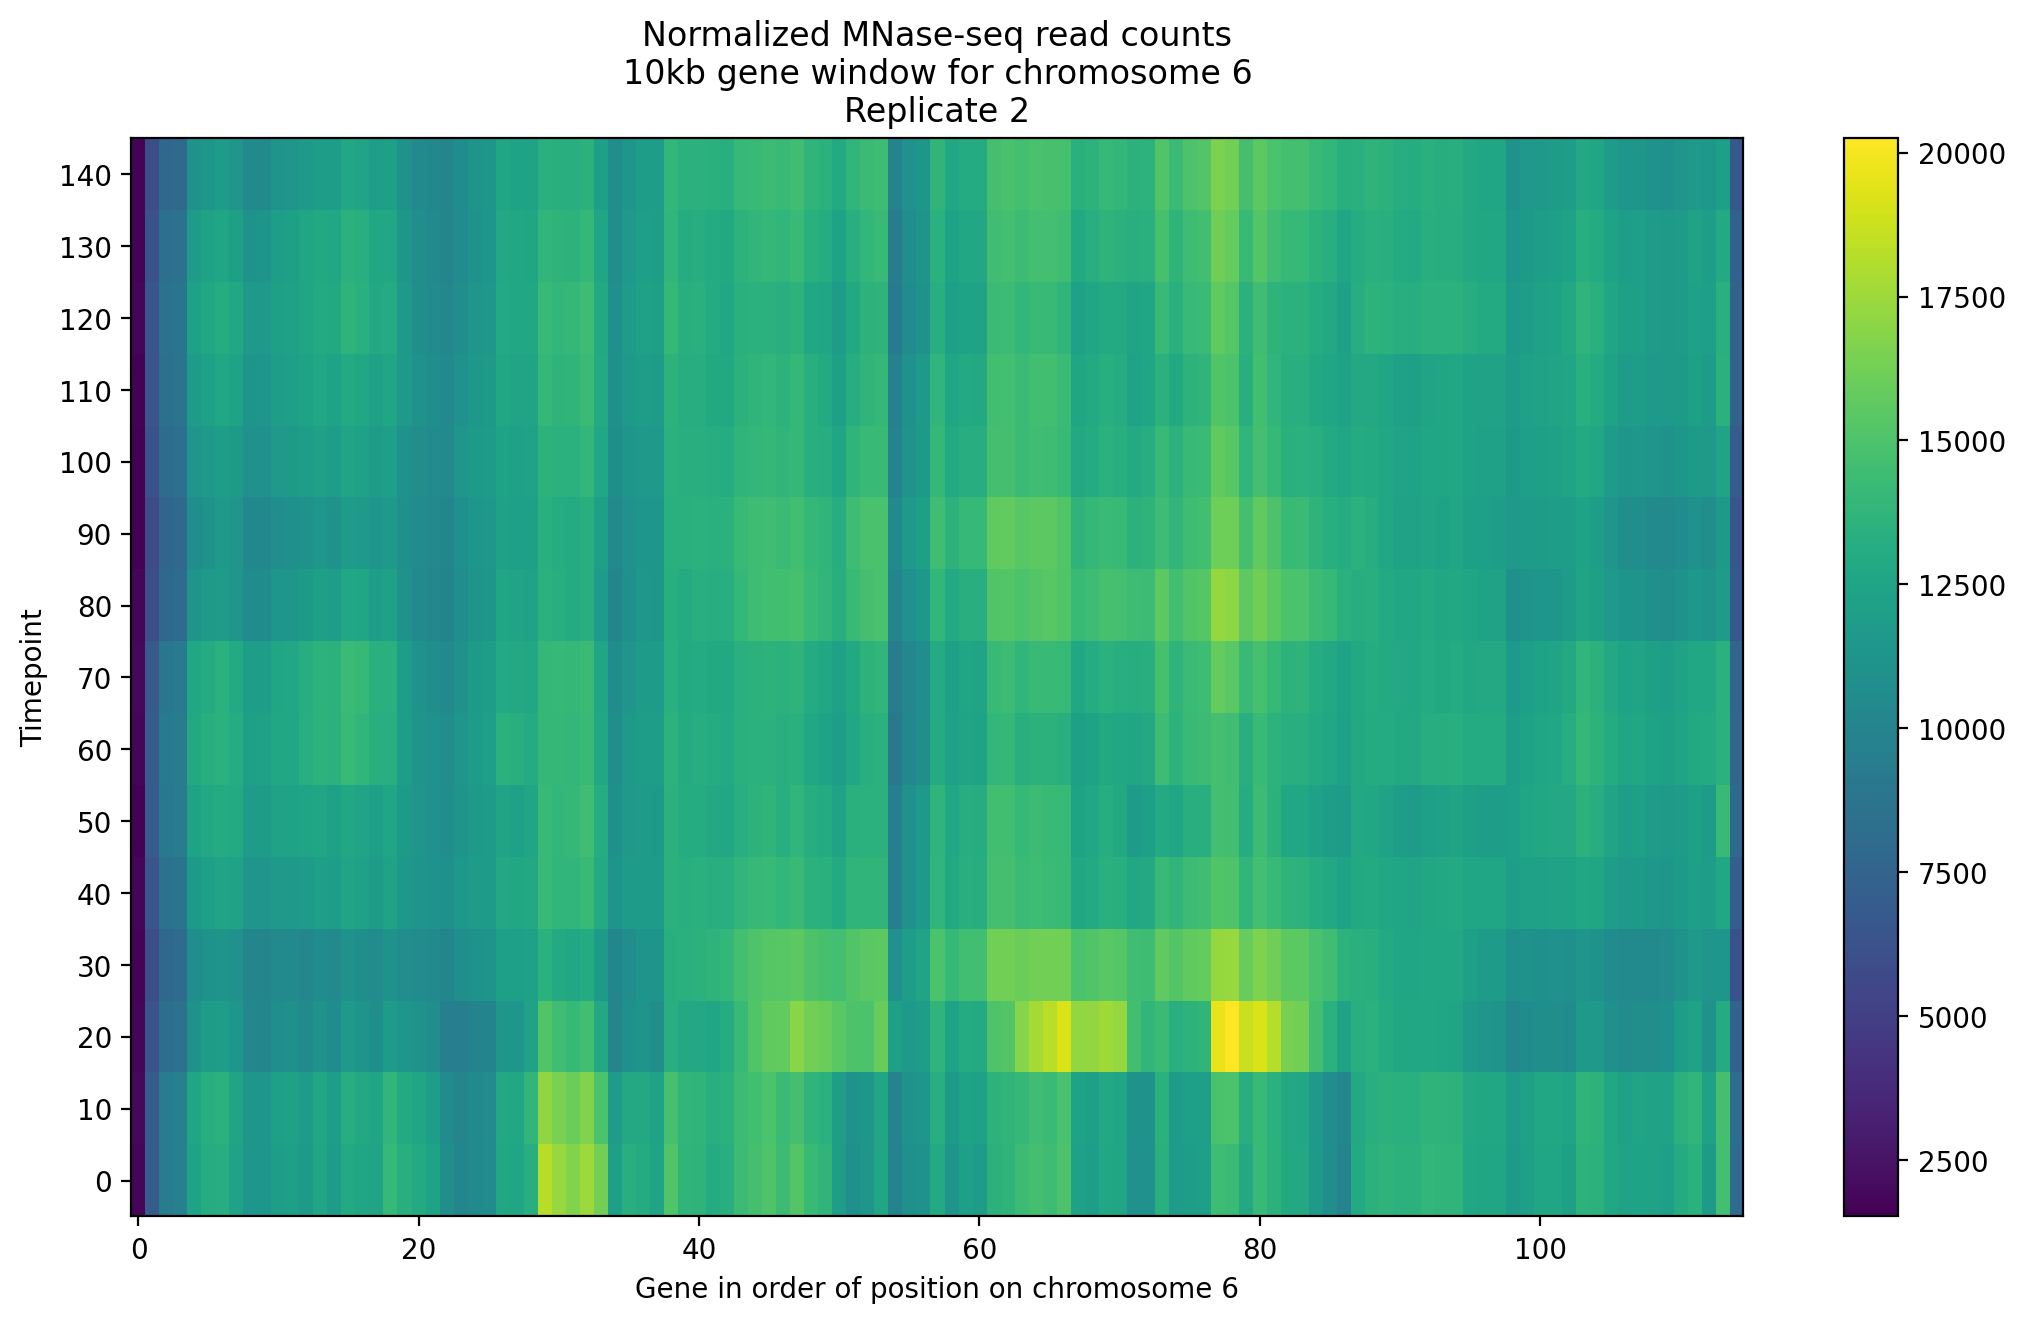

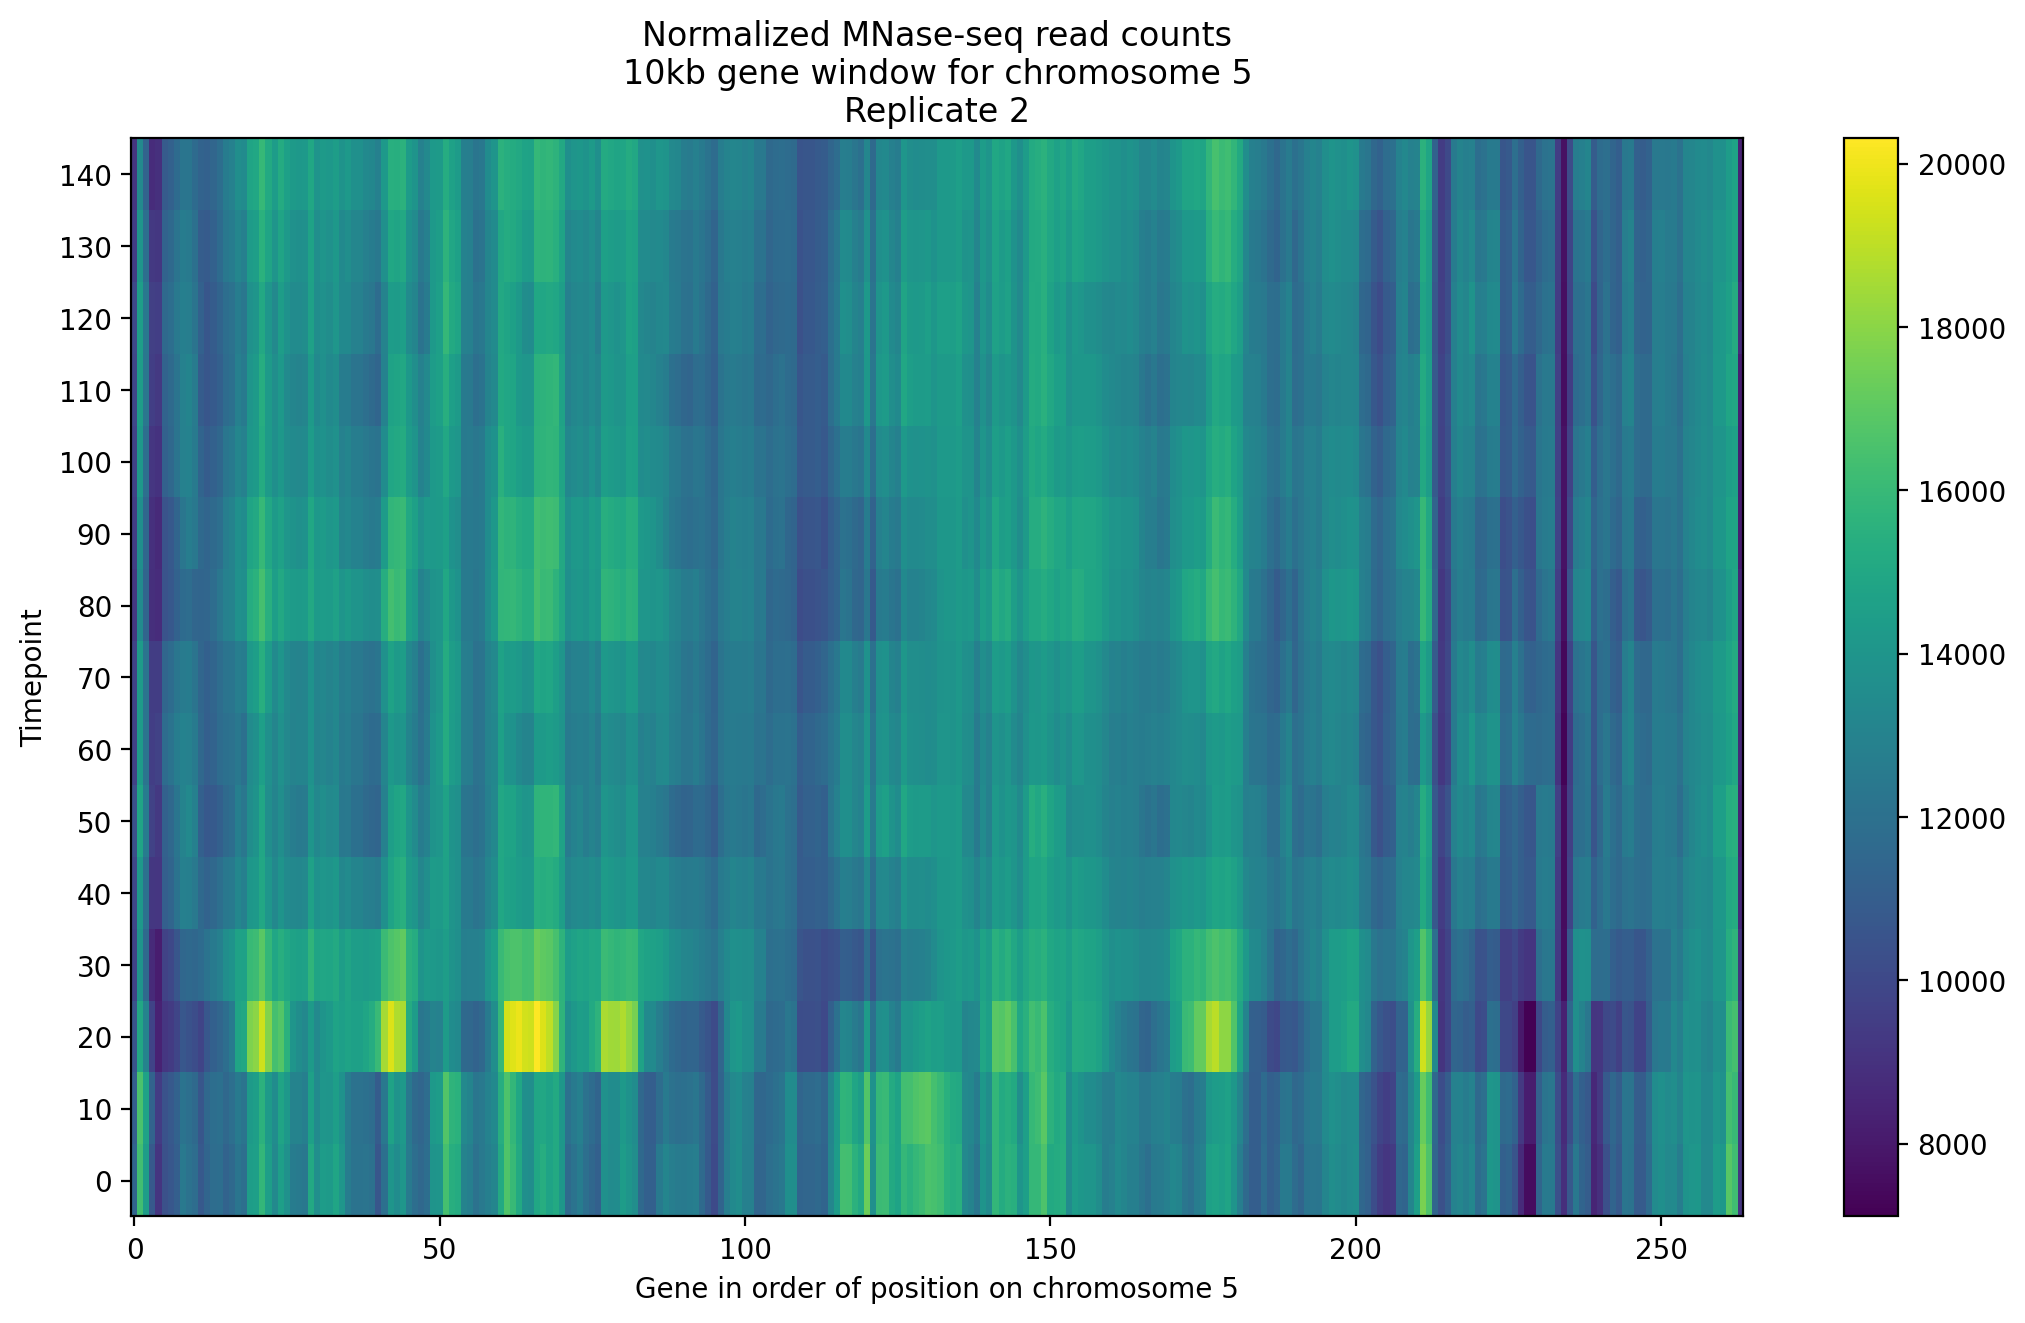

In [9]:
from cc_src.raw_chromatin_analysis import ChromatinDataAnalysis
from src.timer import Timer

timer = Timer()
chroms = [10, 3, 6, 5]

for replicate in [1, 2]:
    for chrom in chroms:
        analysis = ChromatinDataAnalysis()

        analysis.set_chrom_replicate(chromosome=chrom, replicate=replicate)
        analysis.create_gene_mnase_histogram(timer)
        analysis.normalize()

        analysis.plot_normalized_gene_sums()
        plt.savefig(f"output/raw_data_sum_analysis/chr{chrom}_rep{replicate}.png", dpi=150)
